In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
!pip install tensorflow

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image and batch settings
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

# Defining paths to the two directories of the dataset
train_path = r"C:\Users\nithy\OneDrive\Attachments\Desktop\New folder (4)\Covid19-dataset\train"
test_path = r"C:\Users\nithy\OneDrive\Attachments\Desktop\New folder (4)\Covid19-dataset\test"


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation strategies for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Separate augmentation for validation and test data
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load dataset from directories
train_generator = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    directory=train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    directory=test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


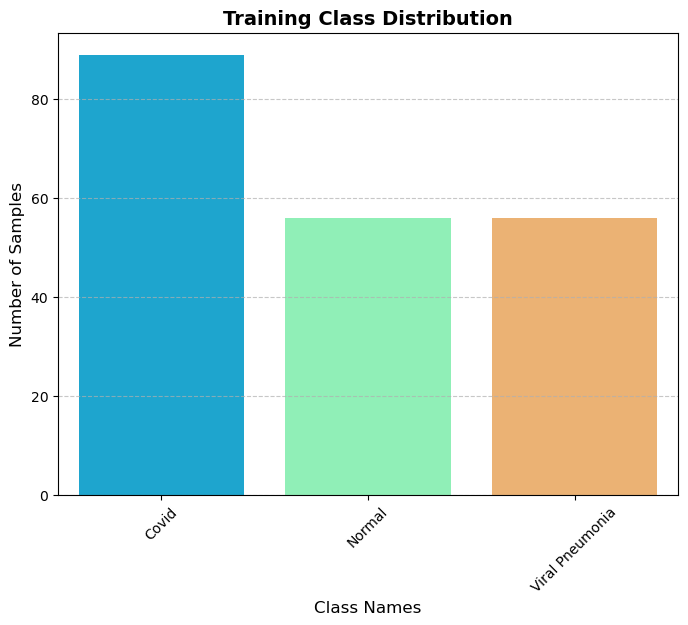

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = list(train_generator.class_indices.keys())
class_counts = [0] * len(class_names)

for label in train_generator.classes:
    class_counts[label] += 1

plt.figure(figsize=(8, 6))
sns.barplot(x=class_names, y=class_counts, palette="rainbow")  # Using a colorful palette
plt.title("Training Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


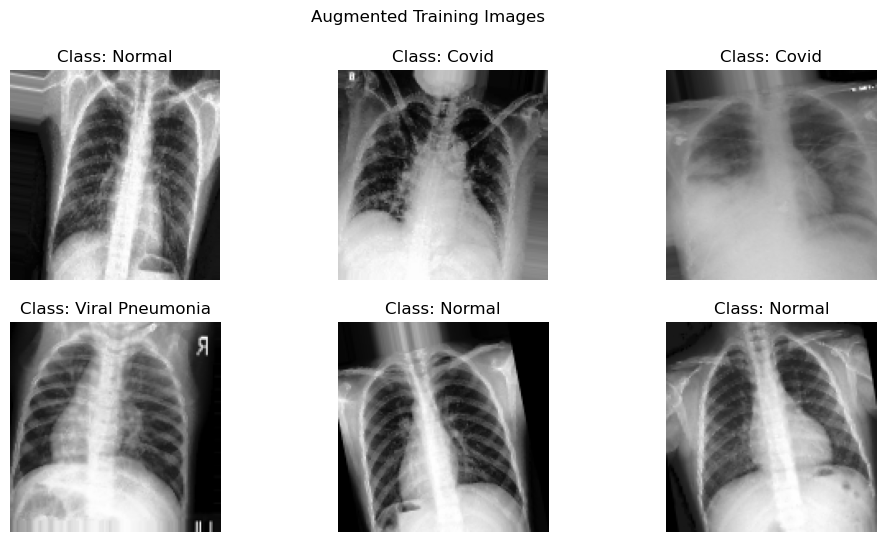

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve a batch of images and labels from the training generator
images, labels = next(train_generator)

# Create a figure for displaying images
plt.figure(figsize=(12, 6))

# Loop through the first six images and display them
for i in range(6):
    plt.subplot(2, 3, i+1)  # Arrange images in a 2x3 grid
    plt.imshow(images[i])  # Show the image
    class_label = np.argmax(labels[i])  # Convert one-hot labels to class index
    plt.title(f"Class: {class_names[class_label]}")  # Display class name
    plt.axis('off')  # Remove axes for a cleaner look

# Set a title for the entire figure
plt.suptitle("Augmented Training Images")

# Render the images
plt.show()


In [9]:
import numpy as np
from sklearn.utils import class_weight

# Retrieve class labels from the training generator
y_classes = train_generator.classes

# Compute balanced class weights based on label distribution
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_classes),
    y=y_classes
)

# Convert computed weights into a dictionary format for easier use
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)


Class Weights: {0: 0.7528089887640449, 1: 1.1964285714285714, 2: 1.1964285714285714}


In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define model using Functional API
inputs = Input(shape=(128, 128, 3), name='input_layer')  # Input layer for 128x128 RGB images

x = Conv2D(32, (3, 3), activation='relu')(inputs)  # First convolutional layer
x = MaxPooling2D(2, 2)(x)  # Max pooling to reduce spatial dimensions

x = Conv2D(64, (3, 3), activation='relu')(x)  # Second convolutional layer
x = MaxPooling2D(2, 2)(x)

x = Conv2D(128, (3, 3), activation='relu')(x)  # Third convolutional layer
x = MaxPooling2D(2, 2)(x)

x = Flatten()(x)  # Flatten feature maps into a single vector
x = Dense(128, activation='relu', name='dense_embedding')(x)  # Fully connected layer
x = Dropout(0.5)(x)  # Dropout to prevent overfitting

outputs = Dense(3, activation='softmax')(x)  # Output layer with softmax for multi-class classification

# Final model definition
model = Model(inputs=inputs, outputs=outputs)

# Compile the model with Adam optimizer and categorical crossentropy loss
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [11]:
# Extract features from the trained model using the dense embedding layer
feature_extractor = Model(inputs=model.input, outputs=model.get_layer("dense_embedding").output)


In [12]:
# Train the CNN model using the training and validation datasets
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,  # Number of training iterations
    class_weight=class_weight_dict,  # Adjust class imbalance
    verbose=1  # Display training progress
)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3078 - loss: 1.4777 - val_accuracy: 0.2800 - val_loss: 1.0998
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2851 - loss: 1.0563 - val_accuracy: 0.4800 - val_loss: 0.8934
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6903 - loss: 0.8343 - val_accuracy: 0.7200 - val_loss: 0.6890
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7272 - loss: 0.7687 - val_accuracy: 0.8000 - val_loss: 0.5783
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 993ms/step - accuracy: 0.6851 - loss: 0.6750 - val_accuracy: 0.7800 - val_loss: 0.5780
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 992ms/step - accuracy: 0.7949 - loss: 0.5444 - val_accuracy: 0.8000 - val_loss: 0.5305
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 939ms/step - accuracy: 0.8225 - loss: 0.4898 - val_accuracy: 0.8400 - val_loss: 0.4942
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 928ms/step - accuracy: 0.8614 - loss: 0.4105 - val_accuracy: 0.8800

In [13]:
# Reset the test generator to ensure consistent batch ordering
test_generator.reset()

# Retrieve a batch of test images and labels
x_imgs, y_labels = next(test_generator)

# Extract features using the trained model
x_features = feature_extractor.predict(x_imgs)

# Convert one-hot encoded labels to class indices
y_true = np.argmax(y_labels, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


In [14]:
from sklearn.model_selection import train_test_split

# Split features and labels into training and validation sets while maintaining class distribution
X_train, X_val, y_train, y_val = train_test_split(x_features, y_true, test_size=0.25, random_state=42, stratify=y_true)


In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Define a grid of hyperparameters to tune for the MLP model
param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],  # Different configurations of hidden layers
    'activation': ['relu'],  # Using ReLU activation function for non-linearity
    'solver': ['adam'],  # Adam optimizer for efficient weight updates
    'alpha': [0.0001, 0.001],  # Regularization strength to prevent overfitting
    'learning_rate': ['constant', 'adaptive']  # Learning rate strategies
}

# Initialize the base MLP model with a maximum of 300 iterations
mlp = MLPClassifier(max_iter=300, random_state=42)

# Perform hyperparameter tuning using GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation to evaluate different parameter combinations
    verbose=2,  # Display detailed progress during tuning
    n_jobs=-1  # Utilize all available CPU cores for faster computation
)

# Train the model using the best hyperparameter combination found
grid_search.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = grid_search.predict(X_val)

# Display the best hyperparameters found during tuning
print("Best Hyperparameters:", grid_search.best_params_)

# Print the validation accuracy of the optimized MLP model
print("Validation Accuracy (MLP):", accuracy_score(y_val, y_pred))

# Generate a classification report to evaluate precision, recall, and F1-score
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Hyperparameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'constant', 'solver': 'adam'}
Validation Accuracy (MLP): 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest model with 100 decision trees
rf = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    max_depth=None,  # No restriction on tree depth, allowing full growth
    random_state=42  # Ensures reproducibility of results
)

# Train the model using the training dataset
rf.fit(X_train, y_train)

# Make predictions on the validation dataset
y_pred_rf = rf.predict(X_val)

# Calculate the accuracy of the model on validation data
accuracy_rf = accuracy_score(y_val, y_pred_rf)

# Display the validation accuracy of the trained Random Forest model
print(f"Validation Accuracy (Random Forest): {accuracy_rf:.2f}")

# Generate a classification report to evaluate precision, recall, and F1-score
print("\nClassification Report:\n", classification_report(y_val, y_pred_rf))


Validation Accuracy (Random Forest): 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define a grid of hyperparameters to tune for the Random Forest model
param_grid_rf = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_depth': [None, 10, 20],  # Maximum depth of each tree (None allows full growth)
    'min_samples_split': [2, 4]  # Minimum samples required to split a node
}

# Perform hyperparameter tuning using GridSearchCV with cross-validation
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, n_jobs=-1, verbose=2)
grid_rf.fit(X_train, y_train)  # Train the model using different hyperparameter combinations

# Retrieve the best model found during grid search
best_rf = grid_rf.best_estimator_

# Make predictions on the validation dataset using the optimized model
y_pred_rf = best_rf.predict(X_val)

# Calculate the accuracy of the tuned Random Forest model
accuracy_rf = accuracy_score(y_val, y_pred_rf)

# Display the best hyperparameters found during tuning
print("Best Hyperparameters:", grid_rf.best_params_)

# Print the validation accuracy of the optimized Random Forest model
print(f"Validation Accuracy (Tuned RF): {accuracy_rf:.2f}")

# Generate a classification report to evaluate precision, recall, and F1-score
print("\nClassification Report:\n", classification_report(y_val, y_pred_rf))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Validation Accuracy (Tuned RF): 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import numpy as np

# Reset the test generator to ensure consistent ordering of test data
test_generator.reset()

# Initialize lists to store test images and labels
x_test_raw = []
y_test_raw = []

# Iterate through the test generator to retrieve all batches of test data
for i in range(len(test_generator)):
    x_batch, y_batch = next(test_generator)  # Get a batch of images and labels
    x_test_raw.append(x_batch)  # Append images to the list
    y_test_raw.append(y_batch)  # Append labels to the list

# Convert lists into NumPy arrays for easier manipulation
x_test_raw = np.vstack(x_test_raw)  # Stack images into a single array (N, 128, 128, 3)
y_test_raw = np.argmax(np.vstack(y_test_raw), axis=1)  # Convert one-hot encoded labels to class indices (N,)

# Flatten image data from (N, 128, 128, 3) to (N, 49152) for clustering
x_test_flat = x_test_raw.reshape(len(x_test_raw), -1)

# Apply KMeans clustering to group images into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred_kmeans = kmeans.fit_predict(x_test_flat)  # Predict cluster assignments for each image

# Function to align predicted clusters with actual labels using the Hungarian algorithm
def map_clusters(y_true, y_pred):
    D = confusion_matrix(y_true, y_pred)  # Compute confusion matrix between true labels and predicted clusters
    row_ind, col_ind = linear_sum_assignment(-D)  # Solve optimal label assignment using Hungarian algorithm
    mapping = dict(zip(col_ind, row_ind))  # Create a mapping from predicted clusters to actual labels
    return np.array([mapping[label] for label in y_pred])  # Apply mapping to predicted labels

# Align predicted clusters with actual labels
y_pred_aligned = map_clusters(y_test_raw, y_pred_kmeans)

# Evaluate clustering performance
acc = accuracy_score(y_test_raw, y_pred_aligned)  # Compute accuracy of cluster assignments
ari = adjusted_rand_score(y_test_raw, y_pred_kmeans)  # Compute Adjusted Rand Index for clustering quality

# Print evaluation metrics
print(f"Clustering Accuracy (raw pixels): {acc:.2f}")
print(f"Adjusted Rand Index: {ari:.2f}")


Clustering Accuracy (raw pixels): 0.76
Adjusted Rand Index: 0.49


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import numpy as np

# 1. Extract CNN embeddings from the test set
test_generator.reset()  # Reset the test generator to ensure consistent ordering of test data

# Generate feature embeddings using the trained CNN model
x_test_embeddings = feature_extractor.predict(test_generator, verbose=0)

# Initialize a list to store true labels
y_test_labels = []

# Iterate through the test generator to retrieve all batches of test labels
for _ in range(len(test_generator)):
    _, y_batch = next(test_generator)  # Extract labels from each batch
    y_test_labels.append(y_batch)  # Append labels to the list

# Convert one-hot encoded labels into class indices for evaluation
y_test_labels = np.argmax(np.vstack(y_test_labels), axis=1)

# 2. Apply KMeans clustering on CNN feature embeddings
kmeans_cnn = KMeans(n_clusters=3, random_state=42)  # Define KMeans with 3 clusters
y_pred_cnn = kmeans_cnn.fit_predict(x_test_embeddings)  # Assign clusters to test samples

# 3. Align predicted clusters with true labels using the Hungarian algorithm
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def align_clusters(true_labels, predicted_labels):
    D = confusion_matrix(true_labels, predicted_labels)  # Compute confusion matrix between true labels and predicted clusters
    row_ind, col_ind = linear_sum_assignment(-D)  # Solve optimal label assignment using Hungarian algorithm
    mapping = dict(zip(col_ind, row_ind))  # Create a mapping from predicted clusters to actual labels
    return np.array([mapping[label] for label in predicted_labels])  # Apply mapping to predicted labels

# Align predicted clusters with actual labels
y_pred_aligned = align_clusters(y_test_labels, y_pred_cnn)

# 4. Evaluate clustering performance
from sklearn.metrics import accuracy_score, adjusted_rand_score

acc_cnn = accuracy_score(y_test_labels, y_pred_aligned)  # Compute accuracy of cluster assignments
ari_cnn = adjusted_rand_score(y_test_labels, y_pred_cnn)  # Compute Adjusted Rand Index for clustering quality

# Print evaluation metrics
print(f"Clustering Accuracy (CNN embeddings): {acc_cnn:.2f}")
print(f"Adjusted Rand Index (CNN): {ari_cnn:.2f}")


Clustering Accuracy (CNN embeddings): 0.62
Adjusted Rand Index (CNN): 0.50


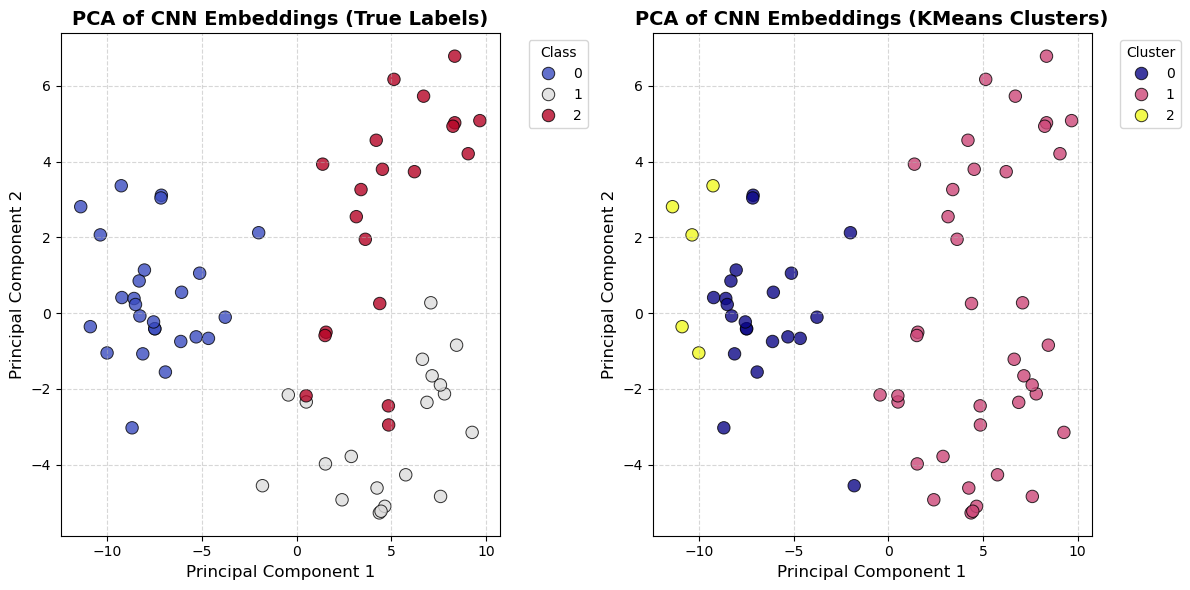

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to reduce CNN embeddings to 2D for visualization
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_test_embeddings)

# Set figure size for better visualization
plt.figure(figsize=(12, 6))

# 1. Plot with True Labels
plt.subplot(1, 2, 1)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_test_labels, palette='coolwarm', s=80, alpha=0.8, edgecolor='black')
plt.title('PCA of CNN Embeddings (True Labels)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Class', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Plot with KMeans Cluster Labels
plt.subplot(1, 2, 2)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_pred_cnn, palette='plasma', s=80, alpha=0.8, edgecolor='black')
plt.title('PCA of CNN Embeddings (KMeans Clusters)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
